# 5. Evaluation (Explainable AI with SHAP)

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split

## 5.1 Load Data dan Model

In [10]:
df = pd.read_csv('../Datasets/prepared_dataset.csv')

# Convert categorical columns
cat_features = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']
for col in cat_features:
    df[col] = df[col].astype('category')

X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']

# Gunakan random_state yang sama untuk mendapatkan X_test yang persis sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Load Model
model = joblib.load('../Models/lightgbm_model.pkl')
print('Model LightGBM dan data uji berhasil dimuat.')

Model LightGBM dan data uji berhasil dimuat.


## 5.2 SHAP Explainer

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

## 5.3 SHAP Summary Plot

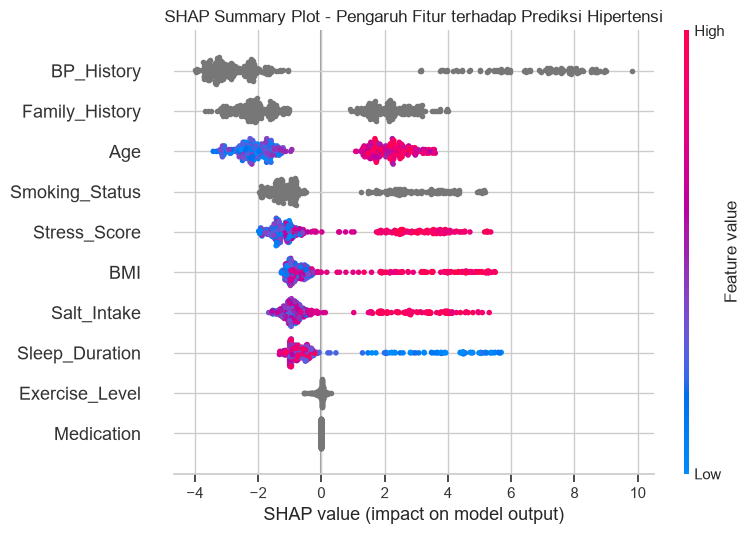

In [12]:
plt.figure()
shap.summary_plot(shap_values_plot, X_test, show=False)
plt.title('SHAP Summary Plot - Pengaruh Fitur terhadap Prediksi Hipertensi')
plt.tight_layout()
plt.show()

## 5.4 SHAP Feature Importance

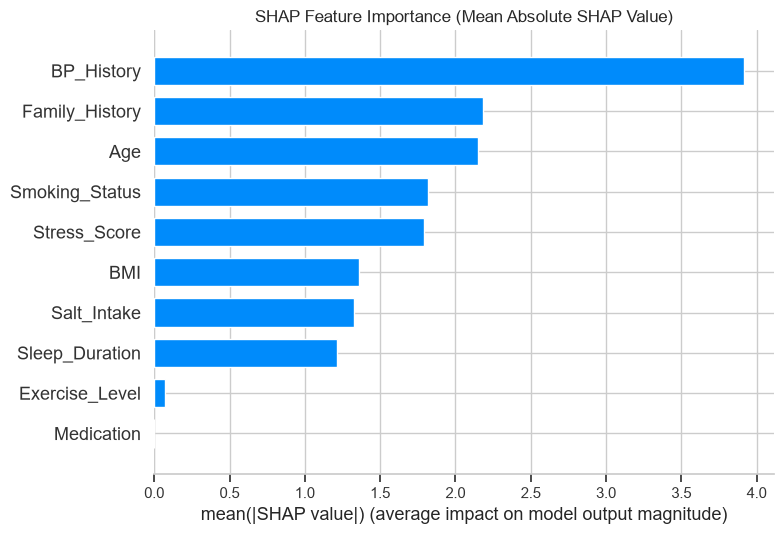

In [13]:
plt.figure()
shap.summary_plot(shap_values_plot, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean Absolute SHAP Value)')
plt.tight_layout()
plt.show()

## 5.5 SHAP Dependence Plot

<Figure size 640x480 with 0 Axes>

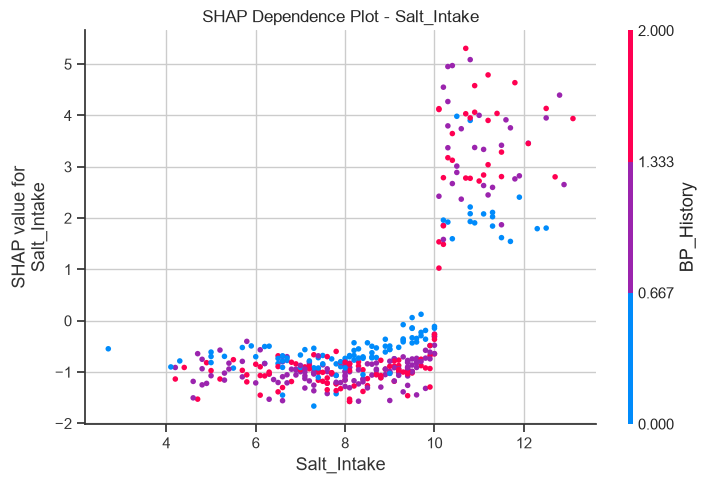

In [14]:
plt.figure()
shap.dependence_plot('Salt_Intake', shap_values_plot, X_test, show=False)
plt.title('SHAP Dependence Plot - Salt_Intake')
plt.tight_layout()
plt.show()

## 5.6 SHAP Waterfall Plot

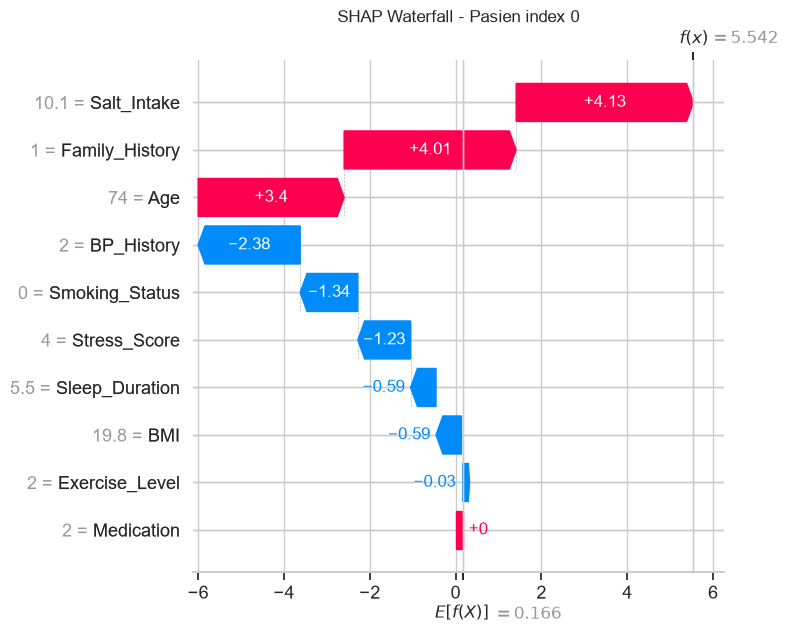

In [15]:
sample_idx = 0
explainer_exp = shap.Explainer(model)
shap_exp_values = explainer_exp(X_test)

plt.figure()
shap.plots.waterfall(shap_exp_values[sample_idx], show=False)
plt.title(f'SHAP Waterfall - Pasien index {sample_idx}')
plt.tight_layout()
plt.show()

## 5.7 Ranking Fitur Paling Berpengaruh

In [16]:
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_plot).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("=== RANKING FITUR BERDASARKAN SHAP ===")
print(feature_importance)

=== RANKING FITUR BERDASARKAN SHAP ===
          Feature  Mean_Abs_SHAP
3      BP_History       3.919268
7  Family_History       2.183655
0             Age       2.149546
9  Smoking_Status       1.821195
2    Stress_Score       1.794558
5             BMI       1.361261
1     Salt_Intake       1.325747
4  Sleep_Duration       1.213803
8  Exercise_Level       0.069508
6      Medication       0.000000
